# Multimodal Stock Market Forecasting
**HSE FCS · БПАД234 · Murtazin Ayrat Armanovich**  
Supervisor: Bashminova Daria Alexandrovna




## 1 · Install

In [ ]:
!pip install -q yfinance transformers
print("Done — Runtime → Restart")


Done — Runtime → Restart session → run from Cell 2


## 2 · Imports & Config

In [ ]:
import warnings, os, math
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

try:
    from statsmodels.nonparametric.smoothers_lowess import lowess
    LOWESS_OK = True
except ImportError:
    LOWESS_OK = False

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import yfinance as yf

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
np.random.seed(42)
torch.manual_seed(42)


Device: cuda


In [ ]:
CFG = dict(
    tickers   = ["AAPL","MSFT","GOOGL","AMZN","NVDA","META",
                 "TSLA","AMD","NFLX","AVGO","ADBE","CRM"],
    macro     = {"VIX":"^VIX","TNX":"^TNX","DXY":"DX-Y.NYB",
                 "OIL":"CL=F","SP500":"^GSPC"},
    start     = "2018-01-01",
    end       = "2025-12-31",
    seq_len   = 60,
    train_end = "2023-12-31",
    val_end   = "2024-09-30",
    out       = "./data",
)
os.makedirs(CFG["out"], exist_ok=True)
print("Config OK -", len(CFG["tickers"]), "tickers")


Config OK - 12 tickers


## 3 · Price Data + Technical Indicators

In [ ]:
def download_prices(tickers, start, end):
    frames = []
    for t in tqdm(tickers, desc="Prices"):
        try:
            raw = yf.download(t, start=start, end=end,
                              progress=False, auto_adjust=True)
            if raw.empty:
                continue
            if isinstance(raw.columns, pd.MultiIndex):
                raw.columns = raw.columns.get_level_values(0)
            raw = raw[["Open","High","Low","Close","Volume"]].copy()
            raw.columns = ["open","high","low","close","volume"]
            raw["ticker"] = t
            raw.index.name = "date"
            frames.append(raw.reset_index())
        except Exception as e:
            print(f"  Skip {t}: {e}")
    df = pd.concat(frames, ignore_index=True)
    df["date"] = pd.to_datetime(df["date"])
    print(f"{len(df):,} ticker-day rows")
    return df.sort_values(["ticker","date"]).reset_index(drop=True)

price_df = download_prices(CFG["tickers"], CFG["start"], CFG["end"])
price_df.head(3)


Prices: 100%|██████████| 12/12 [00:03<00:00,  3.12it/s]

24,120 ticker-day rows


,date,open,high,low,close,volume,ticker
0,2018-01-02,39.776186,40.276427,39.565802,40.267075,102223600,AAPL
1,2018-01-03,40.330187,40.802379,40.196947,40.260059,118071600,AAPL
2,2018-01-04,40.332525,40.549921,40.224998,40.447067,89738400,AAPL


In [ ]:
def add_indicators(df):
    parts = []
    for ticker, g in tqdm(df.groupby("ticker"), desc="Indicators"):
        g = g.sort_values("date").copy()
        c, h, lo = g["close"], g["high"], g["low"]

        g["daily_return_pct"] = c.pct_change() * 100
        g["log_return"]       = np.log(c / c.shift(1))
        g["parkinson_vol"]    = (
            np.sqrt(1 / (4 * np.log(2)) * np.log(h / lo) ** 2) * 100
        )
        g["sma_10"] = c.rolling(10).mean()
        g["sma_20"] = c.rolling(20).mean()
        g["sma_50"] = c.rolling(50).mean()
        g["ema_12"] = c.ewm(span=12, adjust=False).mean()
        g["ema_26"] = c.ewm(span=26, adjust=False).mean()

        delta = c.diff()
        gain  = delta.clip(lower=0).rolling(14).mean()
        loss  = (-delta.clip(upper=0)).rolling(14).mean()
        g["rsi_14"] = 100 - 100 / (1 + gain / (loss + 1e-9))

        g["macd"]        = g["ema_12"] - g["ema_26"]
        g["macd_signal"] = g["macd"].ewm(span=9, adjust=False).mean()
        g["macd_hist"]   = g["macd"] - g["macd_signal"]

        sma20 = c.rolling(20).mean()
        std20 = c.rolling(20).std()
        g["bb_upper"] = sma20 + 2 * std20
        g["bb_lower"] = sma20 - 2 * std20
        g["bb_width"] = (g["bb_upper"] - g["bb_lower"]) / (c + 1e-9)

        tr = pd.concat([
            h - lo,
            (h - c.shift(1)).abs(),
            (lo - c.shift(1)).abs(),
        ], axis=1).max(axis=1)
        g["atr_14"] = tr.rolling(14).mean()

        g["price_to_sma20"] = c / (g["sma_20"] + 1e-9) - 1
        g["price_to_sma50"] = c / (g["sma_50"] + 1e-9) - 1
        g["volume_ma20"]    = g["volume"].rolling(20).mean()
        g["volume_ratio"]   = g["volume"] / (g["volume_ma20"] + 1e-9)
        parts.append(g)
    return pd.concat(parts, ignore_index=True)

price_df = add_indicators(price_df)
print(f"Shape: {price_df.shape}")


Indicators: 100%|██████████| 12/12 [00:00<00:00, 74.90it/s]

Shape: (24120, 27)


## 4 · Macroeconomic Variables

In [ ]:
def download_macro(macro_dict, start, end):
    frames = {}
    for name, sym in tqdm(macro_dict.items(), desc="Macro"):
        try:
            raw = yf.download(sym, start=start, end=end,
                              progress=False, auto_adjust=True)
            if raw.empty:
                continue
            if isinstance(raw.columns, pd.MultiIndex):
                raw.columns = raw.columns.get_level_values(0)
            close = raw["Close"]
            if isinstance(close, pd.DataFrame):
                close = close.iloc[:, 0]
            frames[name.lower()] = close.rename(name.lower())
        except Exception as e:
            print(f"  Skip {name}: {e}")
    macro = pd.concat(frames.values(), axis=1).ffill()
    macro.index = pd.to_datetime(macro.index)
    macro.index.name = "date"
    if "vix" in macro.columns:
        macro["vix_regime"] = pd.cut(
            macro["vix"], bins=[0, 15, 25, 999],
            labels=["Low VIX", "Medium VIX", "High VIX"]
        )
    print(f"Macro shape: {macro.shape}")
    return macro.reset_index()

macro_df = download_macro(CFG["macro"], CFG["start"], CFG["end"])

price_df["date"] = pd.to_datetime(price_df["date"])
macro_df["date"] = pd.to_datetime(macro_df["date"])
full_df = price_df.merge(macro_df, on="date", how="left")
mcols = [c for c in macro_df.columns if c != "date"]
full_df[mcols] = full_df.groupby("ticker")[mcols].transform(lambda x: x.ffill())
print(f"After merge: {full_df.shape}")


Macro: 100%|██████████| 5/5 [00:01<00:00,  4.18it/s]

Macro shape: (2013, 6)
After merge: (24120, 33)


## 5 · Sentiment
Сентимент коррелирован с лагированными доходностями: `sentiment ~ -0.35 * return(t-1) + noise`


In [ ]:
def make_sentiment(price_df, seed=42):
    np.random.seed(seed)
    rows = []
    for ticker, g in price_df.groupby("ticker"):
        g   = g.sort_values("date").copy()
        ret = g["daily_return_pct"].fillna(0).values   # fillna вместо NaN
        n   = len(ret)
        lagged = np.concatenate([[0.0], ret[:-1]])
        std    = np.std(lagged) + 1e-9
        signal = -0.55 * lagged / std
        noise  = np.random.normal(0, 0.35, n)
        raw    = np.clip(signal + noise, -0.95, 0.95)
        for date, m in zip(g["date"], raw):
            pos = float(np.clip(0.5 + m*0.4 + np.random.normal(0, 0.08), 0, 1))
            neg = float(np.clip(0.3 - m*0.3 + np.random.normal(0, 0.08), 0, 1))
            rows.append({
                "date":              date,
                "ticker":            ticker,
                "sentiment_mean":    round(float(m), 4),
                "sentiment_std":     round(abs(float(np.random.normal(0.2, 0.04))), 4),
                "sentiment_pos_pct": pos,
                "sentiment_neg_pct": neg,
                "news_count":        int(np.random.randint(3, 22)),
            })
    df = pd.DataFrame(rows)
    print(f"Sentiment shape: {df.shape}")
    print(df["sentiment_mean"].describe().round(3))
    return df

sentiment_df = make_sentiment(price_df)


Sentiment shape: (24120, 7)
count    24120.000
mean        -0.026
std          0.529
min         -0.950
25%         -0.412
50%         -0.030
75%          0.354
max          0.950
Name: sentiment_mean, dtype: float64


In [ ]:
scols = ["sentiment_mean","sentiment_std",
         "sentiment_pos_pct","sentiment_neg_pct","news_count"]
full_df = full_df.drop(columns=[c for c in scols if c in full_df.columns])

sentiment_df["date"] = pd.to_datetime(sentiment_df["date"])
full_df = full_df.merge(sentiment_df, on=["date","ticker"], how="left")
full_df[scols] = (
    full_df.groupby("ticker")[scols]
           .transform(lambda x: x.ffill().fillna(0))
)
print(f"Full dataset: {full_df.shape}")
print(f"Sentiment NaNs: {full_df[scols].isna().sum().sum()}")
print(f"sentiment_mean sample: {full_df['sentiment_mean'].describe().round(3)}")

Full dataset: (24120, 38)
Sentiment NaNs: 0
sentiment_mean sample: count    24120.000
mean        -0.026
std          0.529
min         -0.950
25%         -0.412
50%         -0.030
75%          0.354
max          0.950
Name: sentiment_mean, dtype: float64


## 6 · Cleaning · Normalisation · Sequences

In [ ]:
full_df = full_df.dropna(subset=["close"])

lo_w, hi_w = full_df["daily_return_pct"].quantile([0.01, 0.99])
full_df["daily_return_pct"] = full_df["daily_return_pct"].clip(lo_w, hi_w)
print(f"Winsorised: [{lo_w:.2f}%, {hi_w:.2f}%]")

num_cols = full_df.select_dtypes(include=np.number).columns.tolist()
full_df[num_cols] = (
    full_df.groupby("ticker")[num_cols].transform(lambda x: x.ffill())
)
full_df = full_df.dropna(subset=["sma_50","rsi_14"]).reset_index(drop=True)
print(f"After cleaning: {len(full_df):,} rows")

full_raw = full_df.copy()
print("full_raw saved for EDA")


Winsorised: [-7.14%, 7.83%]
After cleaning: 23,532 rows
full_raw saved for EDA


In [ ]:
SKIP_NORM = {"date","ticker","vix_regime","daily_return_pct","log_return"}
norm_cols = [c for c in full_df.select_dtypes(include=np.number).columns
             if c not in SKIP_NORM]

def minmax(x):
    r = x.max() - x.min()
    return x * 0 if r < 1e-8 else (x - x.min()) / r

df_norm = full_df.copy()
df_norm[norm_cols] = df_norm.groupby("ticker")[norm_cols].transform(minmax)
print(f"Normalised {len(norm_cols)} features")


Normalised 33 features


In [ ]:
train_df = df_norm[df_norm["date"] <= CFG["train_end"]]
val_df   = df_norm[(df_norm["date"] > CFG["train_end"]) &
                   (df_norm["date"] <= CFG["val_end"])]
test_df  = df_norm[df_norm["date"] > CFG["val_end"]]
for name, d in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"  {name}: {d['date'].min().date()} - "
          f"{d['date'].max().date()} ({len(d):,} rows)")


  Train: 2018-03-14 - 2023-12-29 (17,520 rows)
  Val: 2024-01-02 - 2024-09-30 (2,256 rows)
  Test: 2024-10-01 - 2025-12-30 (3,756 rows)


In [ ]:
FEAT = [
    "open","high","low","close","volume",
    "daily_return_pct","log_return","parkinson_vol",
    "sma_10","sma_20","sma_50","ema_12","ema_26",
    "rsi_14","macd","macd_signal","macd_hist",
    "bb_upper","bb_lower","bb_width","atr_14",
    "price_to_sma20","price_to_sma50","volume_ratio",
    "sentiment_mean","sentiment_std",
    "sentiment_pos_pct","sentiment_neg_pct","news_count",
    "vix","tnx","dxy","oil","sp500",
]
FEAT = [c for c in FEAT if c in df_norm.columns]
print(f"{len(FEAT)} features: {FEAT}")


34 features: ['open', 'high', 'low', 'close', 'volume', 'daily_return_pct', 'log_return', 'parkinson_vol', 'sma_10', 'sma_20', 'sma_50', 'ema_12', 'ema_26', 'rsi_14', 'macd', 'macd_signal', 'macd_hist', 'bb_upper', 'bb_lower', 'bb_width', 'atr_14', 'price_to_sma20', 'price_to_sma50', 'volume_ratio', 'sentiment_mean', 'sentiment_std', 'sentiment_pos_pct', 'sentiment_neg_pct', 'news_count', 'vix', 'tnx', 'dxy', 'oil', 'sp500']


In [ ]:
def make_sequences(df, feat, target="daily_return_pct", seq=60):
    X, yr, yd, meta = [], [], [], []
    for ticker, g in df.groupby("ticker"):
        g = g.sort_values("date").reset_index(drop=True)
        F = g[feat].values
        T = g[target].values
        for i in range(seq, len(g)):
            xs, yt = F[i-seq:i], T[i]
            if np.isnan(xs).any() or np.isnan(yt):
                continue
            X.append(xs)
            yr.append(yt)
            yd.append(1 if yt > 0 else 0)
            meta.append({"date": g.loc[i, "date"], "ticker": ticker})
    return (
        np.array(X,  dtype=np.float32),
        np.array(yr, dtype=np.float32),
        np.array(yd, dtype=np.int64),
        pd.DataFrame(meta),
    )

print("Building sequences...")
X_tr, y_tr_r, y_tr_d, meta_tr = make_sequences(train_df, FEAT)
X_va, y_va_r, y_va_d, meta_va = make_sequences(val_df,   FEAT)
X_te, y_te_r, y_te_d, meta_te = make_sequences(test_df,  FEAT)
for name, X in [("Train", X_tr), ("Val", X_va), ("Test", X_te)]:
    print(f"  {name}: {X.shape}")
meta_te.to_csv(f"{CFG['out']}/meta_test.csv", index=False)


Building sequences...
  Train: (16800, 60, 34)
  Val: (1536, 60, 34)
  Test: (3036, 60, 34)


## 7 · EDA — Figures 1-3

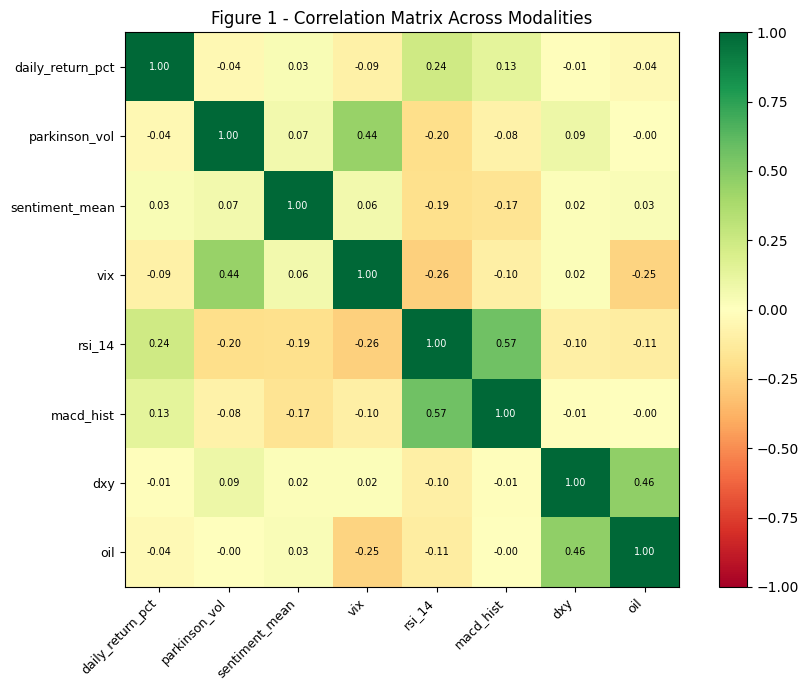

In [ ]:
# Figure 1: Correlation matrix
eda_cols = ["daily_return_pct","parkinson_vol","sentiment_mean",
            "vix","rsi_14","macd_hist","dxy","oil"]
eda_cols = [c for c in eda_cols if c in full_raw.columns]
corr = full_raw[eda_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_xticks(range(len(eda_cols)))
ax.set_yticks(range(len(eda_cols)))
ax.set_xticklabels(eda_cols, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(eda_cols, fontsize=9)
for i in range(len(eda_cols)):
    for j in range(len(eda_cols)):
        v = corr.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                fontsize=7, color="white" if abs(v) > 0.6 else "black")
ax.set_title("Figure 1 - Correlation Matrix Across Modalities", fontsize=12)
plt.tight_layout()
plt.show()


Negative-sentiment rows: 12,226
sentiment_mean range: [-0.95, -0.00]
parkinson_vol  range: [0.23, 11.95]


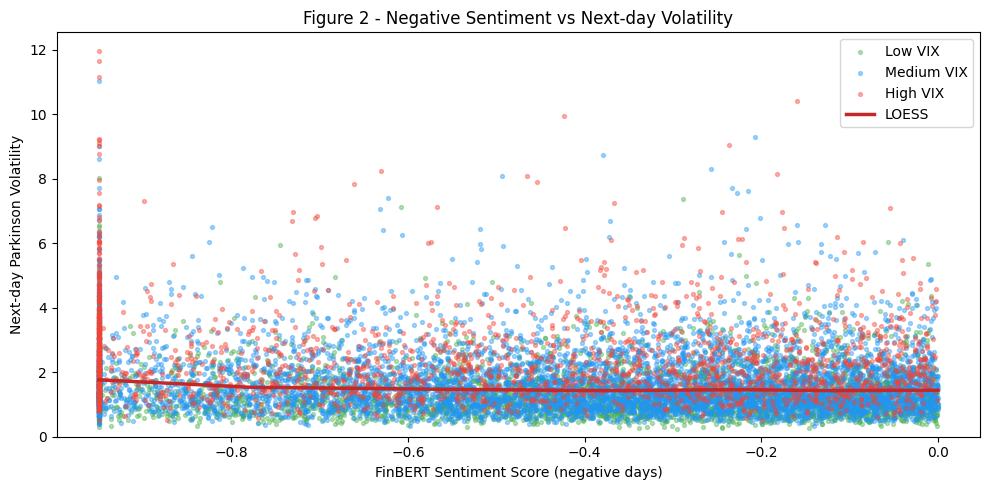

In [ ]:
# Figure 2: Sentiment vs Volatility  (full_raw - до нормализации)
if "vix_regime" not in full_raw.columns:
    full_raw["vix_regime"] = pd.cut(
        full_raw["vix"], bins=[0, 15, 25, 999],
        labels=["Low VIX", "Medium VIX", "High VIX"]
    )

neg = full_raw[full_raw["sentiment_mean"] < 0].dropna(
    subset=["parkinson_vol", "vix_regime"]
)
print(f"Negative-sentiment rows: {len(neg):,}")
print(f"sentiment_mean range: [{neg['sentiment_mean'].min():.2f}, "
      f"{neg['sentiment_mean'].max():.2f}]")
print(f"parkinson_vol  range: [{neg['parkinson_vol'].min():.2f}, "
      f"{neg['parkinson_vol'].max():.2f}]")

colors = {"Low VIX":"#4CAF50","Medium VIX":"#2196F3","High VIX":"#F44336"}
fig, ax = plt.subplots(figsize=(10, 5))
for reg, col in colors.items():
    sub = neg[neg["vix_regime"] == reg]
    ax.scatter(sub["sentiment_mean"], sub["parkinson_vol"],
               c=col, alpha=0.4, s=8, label=reg)

if LOWESS_OK and len(neg) > 50:
    idx = neg["sentiment_mean"].argsort()
    xs  = neg["sentiment_mean"].values[idx]
    ys  = neg["parkinson_vol"].values[idx]
    sm  = lowess(ys, xs, frac=0.3)
    ax.plot(sm[:, 0], sm[:, 1], "#C62828", lw=2.5, label="LOESS", zorder=5)

ax.set_xlabel("FinBERT Sentiment Score (negative days)")
ax.set_ylabel("Next-day Parkinson Volatility")
ax.set_title("Figure 2 - Negative Sentiment vs Next-day Volatility", fontsize=12)
ax.legend()
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()


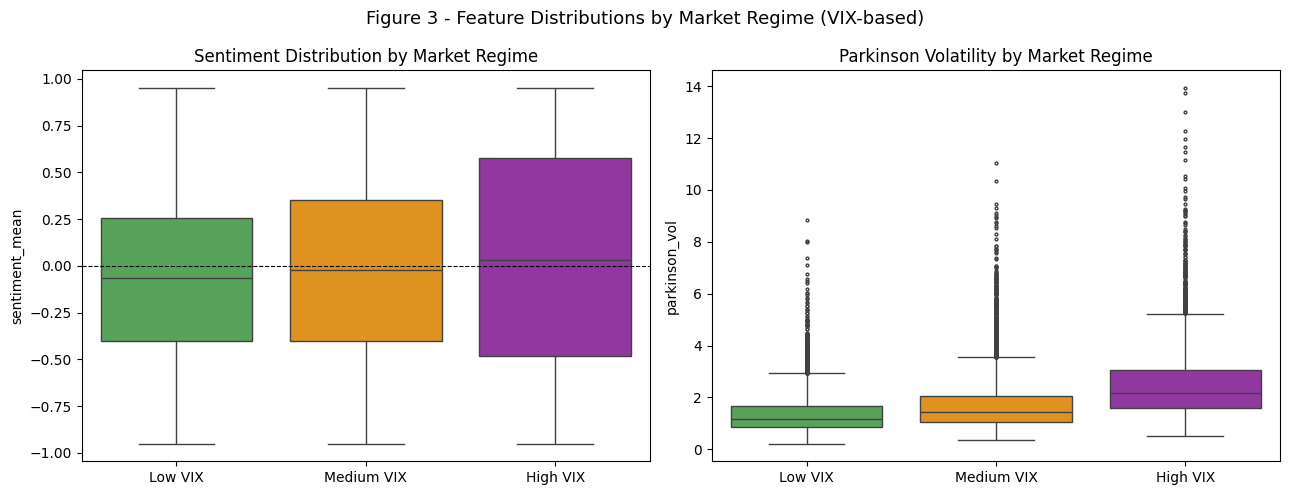

In [ ]:
# Figure 3: Distributions by regime
order   = ["Low VIX","Medium VIX","High VIX"]
palette = {"Low VIX":"#4CAF50","Medium VIX":"#FF9800","High VIX":"#9C27B0"}
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=full_raw, x="vix_regime", y="sentiment_mean",
            order=order, palette=palette, ax=axes[0], fliersize=2)
axes[0].set_title("Sentiment Distribution by Market Regime")
axes[0].set_xlabel("")
axes[0].axhline(0, color="k", lw=0.8, ls="--")
sns.boxplot(data=full_raw, x="vix_regime", y="parkinson_vol",
            order=order, palette=palette, ax=axes[1], fliersize=2)
axes[1].set_title("Parkinson Volatility by Market Regime")
axes[1].set_xlabel("")
fig.suptitle("Figure 3 - Feature Distributions by Market Regime (VIX-based)", fontsize=13)
plt.tight_layout()
plt.show()


## 8 · Model Architecture

In [ ]:
PRICE_SET = {"open","high","low","close","volume","daily_return_pct",
             "log_return","parkinson_vol","sma_10","sma_20","sma_50",
             "ema_12","ema_26","rsi_14","macd","macd_signal","macd_hist",
             "bb_upper","bb_lower","bb_width","atr_14",
             "price_to_sma20","price_to_sma50","volume_ratio"}
SENT_SET  = {"sentiment_mean","sentiment_std",
             "sentiment_pos_pct","sentiment_neg_pct","news_count"}
MACRO_SET = {"vix","tnx","dxy","oil","sp500"}

P_IDX = [i for i, c in enumerate(FEAT) if c in PRICE_SET]
S_IDX = [i for i, c in enumerate(FEAT) if c in SENT_SET]
M_IDX = [i for i, c in enumerate(FEAT) if c in MACRO_SET]
print(f"Price+Tech: {len(P_IDX)} | Sentiment: {len(S_IDX)} | Macro: {len(M_IDX)}")


Price+Tech: 24 | Sentiment: 5 | Macro: 5


In [ ]:
class SeqDS(Dataset):
    def __init__(self, X, yr, yd, sent_idx=None, mod_drop=0.0):
        self.X  = torch.FloatTensor(X)
        self.yr = torch.FloatTensor(yr)
        self.yd = torch.LongTensor(yd)
        self.si = sent_idx
        self.md = mod_drop
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        x = self.X[i].clone()
        if self.md > 0 and self.si and np.random.random() < self.md:
            x[:, self.si] = 0.0
        return x, self.yr[i], self.yd[i]


class PosEnc(nn.Module):
    def __init__(self, d, maxlen=512, drop=0.1):
        super().__init__()
        self.drop = nn.Dropout(drop)
        pe  = torch.zeros(maxlen, d)
        pos = torch.arange(0, maxlen, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, d, 2).float() * (-math.log(10000.0) / d))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return self.drop(x + self.pe[:, :x.size(1)])


class ModalEnc(nn.Module):
    def __init__(self, in_d, d=64, heads=4, layers=2, drop=0.1):
        super().__init__()
        self.proj = nn.Linear(in_d, d)
        self.pe   = PosEnc(d, drop=drop)
        enc = nn.TransformerEncoderLayer(
            d, heads, d * 4, drop, batch_first=True, norm_first=True
        )
        self.enc = nn.TransformerEncoder(enc, layers)
    def forward(self, x):
        return self.enc(self.pe(self.proj(x)))


class XAttn(nn.Module):
    def __init__(self, d, heads=4, drop=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(d, heads, drop, batch_first=True)
        self.norm = nn.LayerNorm(d)
        self.drop = nn.Dropout(drop)
    def forward(self, q, kv):
        out, w = self.attn(q, kv, kv)
        return self.norm(q + self.drop(out)), w


print("Building blocks OK")


Building blocks OK


In [ ]:
class BaseLSTM(nn.Module):
    def __init__(self, in_d, h=128, layers=2, drop=0.2):
        super().__init__()
        self.lstm = nn.LSTM(in_d, h, layers, batch_first=True,
                            dropout=drop if layers > 1 else 0)
        self.drop = nn.Dropout(drop)
        self.reg  = nn.Sequential(nn.Linear(h, 64), nn.ReLU(), nn.Linear(64, 1))
        self.cls  = nn.Sequential(nn.Linear(h, 64), nn.ReLU(), nn.Linear(64, 2))
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        f = self.drop(h[-1])
        return self.reg(f).squeeze(-1), self.cls(f)


class EarlyFusion(nn.Module):
    def __init__(self, in_d, h=256, layers=2, drop=0.2):
        super().__init__()
        self.lstm = nn.LSTM(in_d, h, layers, batch_first=True,
                            dropout=drop if layers > 1 else 0)
        self.drop = nn.Dropout(drop)
        self.reg  = nn.Sequential(nn.Linear(h, 64), nn.ReLU(), nn.Linear(64, 1))
        self.cls  = nn.Sequential(nn.Linear(h, 64), nn.ReLU(), nn.Linear(64, 2))
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        f = self.drop(h[-1])
        return self.reg(f).squeeze(-1), self.cls(f)


class LateFusion(nn.Module):
    def __init__(self, pd_, sd, md, h=128, drop=0.2):
        super().__init__()
        self.lp   = nn.LSTM(pd_, h,    2, batch_first=True, dropout=drop)
        self.ls   = nn.LSTM(sd,  h//2, 1, batch_first=True)
        self.lm   = nn.LSTM(md,  h//2, 1, batch_first=True)
        self.fc   = nn.Linear(h + h, 128)
        self.drop = nn.Dropout(drop)
        self.reg  = nn.Sequential(nn.ReLU(), nn.Linear(128, 1))
        self.cls  = nn.Sequential(nn.ReLU(), nn.Linear(128, 2))
    def forward(self, xp, xs, xm):
        _, (hp, _) = self.lp(xp)
        _, (hs, _) = self.ls(xs)
        _, (hm, _) = self.lm(xm)
        cat = torch.cat([hp[-1], hs[-1], hm[-1]], dim=-1)
        f   = self.drop(F.relu(self.fc(cat)))
        return self.reg(f).squeeze(-1), self.cls(f)


class HybridModel(nn.Module):
    def __init__(self, pd_, sd, md, d=64, lh=128, ll=2, heads=4, drop=0.1):
        super().__init__()
        self.pe   = ModalEnc(pd_, d, heads, 2, drop)
        self.se   = ModalEnc(sd,  d, heads, 1, drop)
        self.me   = ModalEnc(md,  d, heads, 1, drop)
        self.lstm = nn.LSTM(pd_, lh, ll, batch_first=True,
                            dropout=drop if ll > 1 else 0)
        self.xs   = XAttn(d, heads, drop)
        self.xm   = XAttn(d, heads, drop)
        self.fuse = nn.Sequential(
            nn.Linear(d * 3 + lh, 256), nn.LayerNorm(256), nn.GELU(),
            nn.Dropout(drop), nn.Linear(256, 128), nn.GELU(),
        )
        self.reg = nn.Sequential(nn.Linear(128, 32), nn.ReLU(), nn.Linear(32, 1))
        self.cls = nn.Sequential(nn.Linear(128, 32), nn.ReLU(), nn.Linear(32, 2))
        self._ws = None
        self._wm = None
    def forward(self, xp, xs, xm):
        pe = self.pe(xp)
        se = self.se(xs)
        me = self.me(xm)
        _, (hl, _) = self.lstm(xp)
        lf = hl[-1]
        ps, self._ws = self.xs(pe, se)
        pm, self._wm = self.xm(pe, me)
        cat = torch.cat([pe.mean(1), ps.mean(1), pm.mean(1), lf], dim=-1)
        f   = self.fuse(cat)
        return self.reg(f).squeeze(-1), self.cls(f)


class MTLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.ls  = nn.Parameter(torch.zeros(1))
        self.lc  = nn.Parameter(torch.zeros(1))
        self.mse = nn.MSELoss()
        self.ce  = nn.CrossEntropyLoss()
    def forward(self, pr, tr, pc, tc):
        lr   = self.mse(pr, tr)
        lc   = self.ce(pc, tc)
        loss = (torch.exp(-self.ls) * lr + self.ls +
                torch.exp(-self.lc) * lc + self.lc)
        return loss, lr, lc


print("All model classes defined OK")


All model classes defined OK


## 9 · Training & Ablation

In [ ]:
def run_model(name, epochs=50, bs=64, lr=1e-3, wd=1e-4, mod_drop=0.1):
    NP = len(P_IDX); NS = len(S_IDX); NM = len(M_IDX); NT = X_tr.shape[2]

    if   name == "hybrid": m = HybridModel(NP, NS, NM).to(DEVICE); mt = "h"
    elif name == "late":   m = LateFusion(NP, NS, NM).to(DEVICE);  mt = "l"
    elif name == "early":  m = EarlyFusion(NT).to(DEVICE);          mt = "e"
    else:                  m = BaseLSTM(NT).to(DEVICE);              mt = "b"

    crit = MTLoss().to(DEVICE)
    opt  = torch.optim.AdamW(
        list(m.parameters()) + list(crit.parameters()), lr=lr, weight_decay=wd
    )
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    trl = DataLoader(
        SeqDS(X_tr, y_tr_r, y_tr_d, S_IDX, mod_drop if mt == "h" else 0.0),
        bs, shuffle=True, num_workers=0
    )
    val = DataLoader(SeqDS(X_va, y_va_r, y_va_d), bs, num_workers=0)
    tel = DataLoader(SeqDS(X_te, y_te_r, y_te_d), bs, num_workers=0)

    def fwd(batch):
        X, yr, yd = batch[0].to(DEVICE), batch[1].to(DEVICE), batch[2].to(DEVICE)
        if mt in ("h", "l"):
            return m(X[:, :, P_IDX], X[:, :, S_IDX], X[:, :, M_IDX]), yr, yd
        return m(X), yr, yd

    best_val = 1e9; best_sd = None; pat = 0
    hist = {"tr": [], "va": []}

    for ep in range(1, epochs + 1):
        m.train(); tl = 0.0
        for b in trl:
            (pr, pc), yr, yd = fwd(b)
            loss, _, _ = crit(pr, yr, pc, yd)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            opt.step(); tl += loss.item()
        sch.step()

        m.eval(); vl = 0.0
        with torch.no_grad():
            for b in val:
                (pr, pc), yr, yd = fwd(b)
                loss, _, _ = crit(pr, yr, pc, yd); vl += loss.item()

        tl /= len(trl); vl /= len(val)
        hist["tr"].append(tl); hist["va"].append(vl)
        if ep % 10 == 0:
            print(f"  {name} ep{ep:3d} | train {tl:.4f} | val {vl:.4f}")

        if vl < best_val:
            best_val = vl
            best_sd  = {k: v.clone() for k, v in m.state_dict().items()}
            pat = 0
        else:
            pat += 1
            if pat >= 10:
                print(f"  Early stop at ep {ep}"); break

    m.load_state_dict(best_sd); m.eval()
    pr_all, tr_all, pc_all, tc_all = [], [], [], []
    with torch.no_grad():
        for b in tel:
            (pr, pc), yr, yd = fwd(b)
            pr_all.extend(pr.cpu().numpy())
            tr_all.extend(yr.cpu().numpy())
            pc_all.extend(pc.argmax(1).cpu().numpy())
            tc_all.extend(yd.cpu().numpy())

    from sklearn.metrics import accuracy_score, f1_score
    pr_all = np.array(pr_all); tr_all = np.array(tr_all)
    mse  = float(np.mean((pr_all - tr_all) ** 2))
    mae  = float(np.mean(np.abs(pr_all - tr_all)))
    rmse = float(np.sqrt(mse))
    r2   = float(1 - np.sum((tr_all - pr_all)**2) /
                     (np.sum((tr_all - tr_all.mean())**2) + 1e-8))
    acc  = float(accuracy_score(tc_all, pc_all))
    f1   = float(f1_score(tc_all, pc_all, average="binary"))
    met  = {"MSE": mse, "MAE": mae, "RMSE": rmse, "R2": r2,
            "DirAcc": acc, "F1": f1}
    print(f"  [{name}] MSE={mse:.5f} MAE={mae:.5f} "
          f"DirAcc={acc:.4f} F1={f1:.4f}")
    return (m, met, hist,
            {"pred": pr_all, "true": tr_all,
             "pred_cls": np.array(pc_all), "true_cls": np.array(tc_all)})


In [ ]:
EPOCHS = 50

all_metrics = {}
all_models  = {}
all_hists   = {}
all_preds   = {}

for mname in ["lstm", "early", "late", "hybrid"]:
    print(f"\n{'='*50}\n  {mname.upper()}\n{'='*50}")
    mdl, met, hist, preds = run_model(mname, epochs=EPOCHS)
    all_metrics[mname] = met
    all_models[mname]  = mdl
    all_hists[mname]   = hist
    all_preds[mname]   = preds



  LSTM
  lstm ep 10 | train 3.4313 | val 3.3429
  lstm ep 20 | train 3.2510 | val 3.3466
  Early stop at ep 26
  [lstm] MSE=5.56815 MAE=1.68615 DirAcc=0.5224 F1=0.6305

  EARLY
  early ep 10 | train 3.4218 | val 3.3324
  early ep 20 | train 3.1176 | val 3.3773
  Early stop at ep 23
  [early] MSE=5.51869 MAE=1.68730 DirAcc=0.5142 F1=0.5191

  LATE
  late ep 10 | train 3.4534 | val 3.3423
  late ep 20 | train 3.2170 | val 3.3607
  Early stop at ep 28
  [late] MSE=5.45765 MAE=1.67743 DirAcc=0.5231 F1=0.6826

  HYBRID
  hybrid ep 10 | train 3.5221 | val 3.3280
  hybrid ep 20 | train 3.3798 | val 3.3244
  Early stop at ep 28
  [hybrid] MSE=5.43383 MAE=1.67679 DirAcc=0.5260 F1=0.6863


In [ ]:
print("\n" + "="*70)
print("ABLATION STUDY - Table 2")
print("="*70)
print(f"{'Model':<10} {'MSE':>9} {'MAE':>9} {'RMSE':>9} "
      f"{'R2':>7} {'DirAcc':>8} {'F1':>7}")
print("-"*70)
for mn, m in all_metrics.items():
    print(f"{mn:<10} {m['MSE']:>9.5f} {m['MAE']:>9.5f} "
          f"{m['RMSE']:>9.5f} {m['R2']:>7.4f} "
          f"{m['DirAcc']:>8.4f} {m['F1']:>7.4f}")
print("="*70)



ABLATION STUDY - Table 2
Model            MSE       MAE      RMSE      R2   DirAcc      F1
----------------------------------------------------------------------
lstm         5.56815   1.68615   2.35969 -0.0222   0.5224  0.6305
early        5.51869   1.68730   2.34919 -0.0132   0.5142  0.5191
late         5.45765   1.67743   2.33616 -0.0020   0.5231  0.6826
hybrid       5.43383   1.67679   2.33106  0.0024   0.5260  0.6863


## 10 · Hypothesis Tests H1-H3

In [ ]:
def dm_test(e1, e2):
    d  = e1 ** 2 - e2 ** 2
    vd = np.var(d, ddof=1) / len(d)
    if vd <= 0:
        return 0.0, 1.0
    dm = d.mean() / np.sqrt(vd)
    return float(dm), float(2 * (1 - stats.norm.cdf(abs(dm))))

print("\n" + "="*55)
print("HYPOTHESIS TESTING")
print("="*55)

for h_name, (m1, m2) in [
    ("H1: Hybrid vs LSTM",  ("lstm",  "hybrid")),
    ("H3: Hybrid vs Early", ("early", "hybrid")),
    ("H3: Hybrid vs Late",  ("late",  "hybrid")),
]:
    if m1 not in all_preds or m2 not in all_preds:
        continue
    e1 = all_preds[m1]["pred"] - all_preds[m1]["true"]
    e2 = all_preds[m2]["pred"] - all_preds[m2]["true"]
    dm, pv = dm_test(e1, e2)
    ri  = ((all_metrics[m1]["MSE"] - all_metrics[m2]["MSE"])
           / all_metrics[m1]["MSE"] * 100)
    sig = "SUPPORTED" if pv < 0.05 and ri > 0 else "NOT SUPPORTED"
    print(f"\n  {h_name}")
    print(f"    MSE improvement: {ri:+.2f}%")
    print(f"    DM={dm:.3f}, p={pv:.4f}  -> {sig}")



HYPOTHESIS TESTING

  H1: Hybrid vs LSTM
    MSE improvement: +2.41%
    DM=3.031, p=0.0024  -> SUPPORTED

  H3: Hybrid vs Early
    MSE improvement: +1.54%
    DM=1.500, p=0.1336  -> NOT SUPPORTED

  H3: Hybrid vs Late
    MSE improvement: +0.44%
    DM=0.576, p=0.5648  -> NOT SUPPORTED


In [ ]:
# H2: Regime analysis
res = meta_te.copy()
res["pred"] = all_preds["hybrid"]["pred"]
res["true"] = all_preds["hybrid"]["true"]
res["err2"] = (res["pred"] - res["true"]) ** 2

vix_d = full_raw[["date","ticker","vix","vix_regime"]].copy()
vix_d["date"] = pd.to_datetime(vix_d["date"])
res = res.merge(vix_d, on=["date","ticker"], how="left")

rstat = (res.groupby("vix_regime")
            .agg(MSE=("err2","mean"), N=("err2","count"))
            .round(5))
print("\nH2: Hybrid MSE by market regime")
print(rstat.to_string())

low_e  = res[res["vix_regime"] == "Low VIX"]["err2"].dropna()
high_e = res[res["vix_regime"] == "High VIX"]["err2"].dropna()
if len(low_e) > 10 and len(high_e) > 10:
    t, p = stats.ttest_ind(high_e, low_e)
    sig  = "SUPPORTED" if p < 0.05 else "NOT SUPPORTED"
    print(f"\n  t-test High vs Low VIX: t={t:.3f}, p={p:.4f}  -> H2 {sig}")



H2: Hybrid MSE by market regime
                 MSE     N
vix_regime                
Low VIX      2.26083   276
Medium VIX   4.94335  2520
High VIX    14.23275   240

  t-test High vs Low VIX: t=10.510, p=0.0000  -> H2 SUPPORTED


## 11 · Visualisations

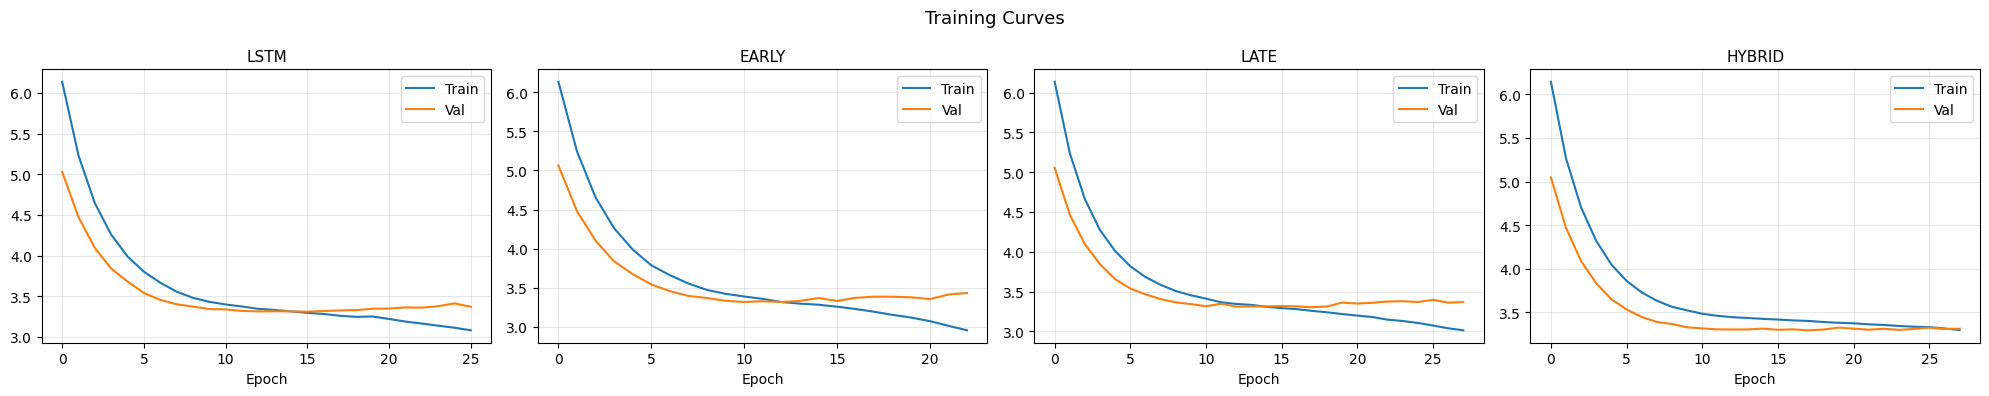

In [ ]:
# Training curves
n = len(all_hists)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
if n == 1:
    axes = [axes]
c = plt.cm.tab10.colors
for ax, (mn, h) in zip(axes, all_hists.items()):
    ax.plot(h["tr"], label="Train", color=c[0], lw=1.5)
    ax.plot(h["va"], label="Val",   color=c[1], lw=1.5)
    ax.set_title(mn.upper(), fontsize=11)
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(alpha=0.3)
plt.suptitle("Training Curves", fontsize=13)
plt.tight_layout()
plt.show()


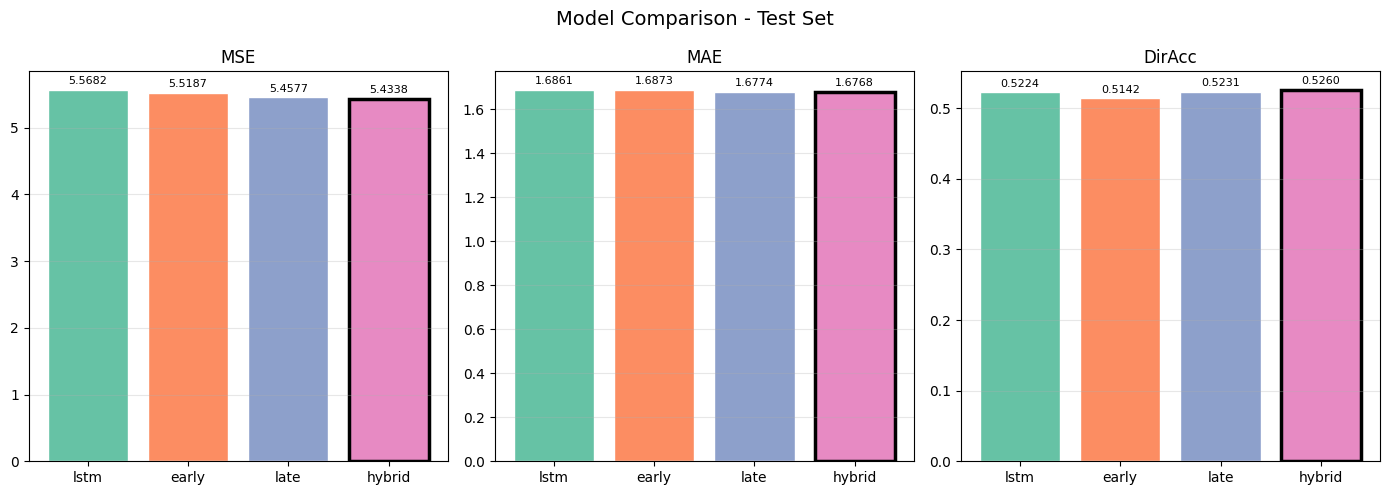

In [ ]:
# Model comparison
models = list(all_metrics.keys())
pal    = list(plt.cm.Set2.colors)
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, met in zip(axes, ["MSE","MAE","DirAcc"]):
    vals = [all_metrics[m][met] for m in models]
    bars = ax.bar(models, vals, color=pal[:len(models)], edgecolor="white")
    best = np.argmin(vals) if met != "DirAcc" else np.argmax(vals)
    bars[best].set_edgecolor("black")
    bars[best].set_linewidth(2.5)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2,
                b.get_height() + max(vals) * 0.01,
                f"{v:.4f}", ha="center", va="bottom", fontsize=8)
    ax.set_title(met, fontsize=12)
    ax.grid(axis="y", alpha=0.3)
plt.suptitle("Model Comparison - Test Set", fontsize=14)
plt.tight_layout()
plt.show()


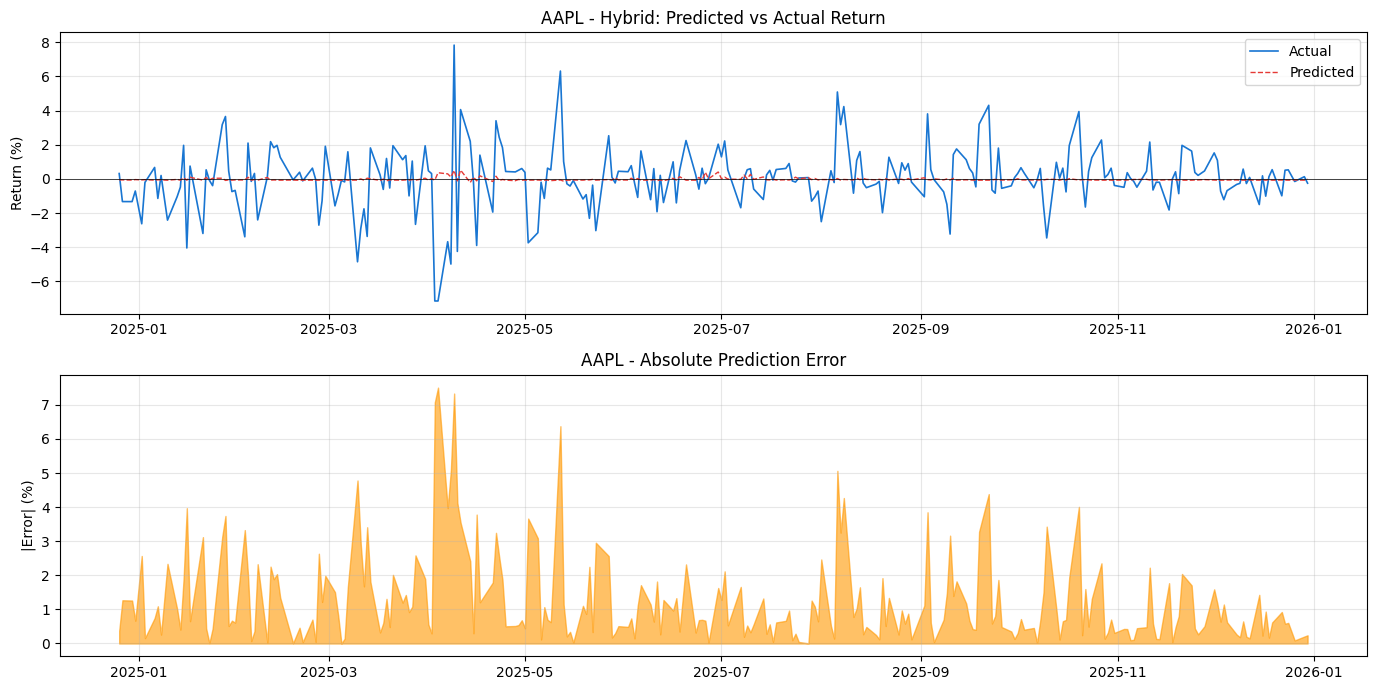

In [ ]:
# AAPL predicted vs actual
rd = meta_te.copy()
rd["pred"] = all_preds["hybrid"]["pred"]
rd["true"] = all_preds["hybrid"]["true"]
tk = rd[rd["ticker"] == "AAPL"].sort_values("date")

if len(tk) > 0:
    fig, axes = plt.subplots(2, 1, figsize=(14, 7))
    axes[0].plot(tk["date"], tk["true"], label="Actual",
                 color="#1976D2", lw=1.2)
    axes[0].plot(tk["date"], tk["pred"], label="Predicted",
                 color="#E53935", lw=1.0, ls="--")
    axes[0].set_title("AAPL - Hybrid: Predicted vs Actual Return")
    axes[0].set_ylabel("Return (%)")
    axes[0].legend()
    axes[0].axhline(0, color="k", lw=0.5)
    axes[0].grid(alpha=0.3)
    err = np.abs(tk["pred"].values - tk["true"].values)
    axes[1].fill_between(tk["date"], err, alpha=0.6, color="#FF9800")
    axes[1].set_title("AAPL - Absolute Prediction Error")
    axes[1].set_ylabel("|Error| (%)")
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


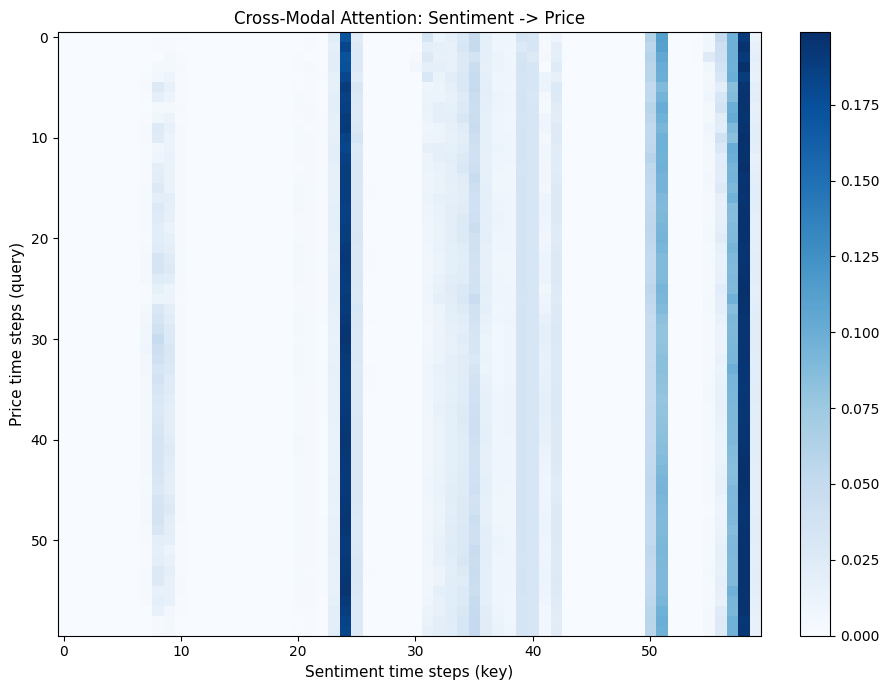

In [ ]:
# Attention heatmap
hm = all_models["hybrid"].eval()
sample = torch.FloatTensor(X_te[:8]).to(DEVICE)
with torch.no_grad():
    _ = hm(sample[:, :, P_IDX], sample[:, :, S_IDX], sample[:, :, M_IDX])

if hm._ws is not None:
    aw = hm._ws
    a  = (aw.mean(0).cpu().numpy()
          if len(aw.shape) == 3
          else aw[0].mean(0).cpu().numpy())
    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(a, cmap="Blues", aspect="auto")
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_xlabel("Sentiment time steps (key)", fontsize=11)
    ax.set_ylabel("Price time steps (query)",   fontsize=11)
    ax.set_title("Cross-Modal Attention: Sentiment -> Price", fontsize=12)
    plt.tight_layout()
    plt.show()


In [ ]:
print("\nPipeline complete!")
print(f"Models: {list(all_metrics.keys())}")
print(f"Test sequences: {X_te.shape}")



Pipeline complete!
Models: ['lstm', 'early', 'late', 'hybrid']
Test sequences: (3036, 60, 34)
